## Data Preparation & Temporal Alignment
I’ll combine year and month and ensure chronological order. I'll synthesize a date column, and cleaning up names to make  plotting code much smoother.

In [2]:
# 1. Load Libraries
library(tidyverse)
library(lubridate)
library(scales)

# 2. Setup Directories
base_dir <- "../../"
clean_data_path <- file.path(base_dir, "data", "cleaned")
african_file <- file.path(clean_data_path, "value_exports_african.csv")

# 3. Read and Clean
df_african_raw <- read.csv(african_file, stringsAsFactors = FALSE)

df_african <- df_african_raw %>%
  # Merge Year and Month into a proper Date object
  dplyr::mutate(date = as.Date(paste(year, month, "01", sep = "-"), format = "%Y-%B-%d")) %>%
  # Rename columns to remove dots and make them professional
  dplyr::rename(
    south_africa = s.africa
  ) %>%
  # Sort chronologically
  dplyr::arrange(date)

# Preview the cleaned data
print("Cleaned African Exports Data Preview:")
head(df_african)


Attaching package: 'lubridate'


The following objects are masked from 'package:base':

    date, intersect, setdiff, union




[1] "Cleaned African Exports Data Preview:"


,year,month,uganda,tanzania,zambia,egypt,rwanda,zimbabwe,ethiopia,somalia,south_africa,drc,other,total,date
,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<date>
1,1998,January,1386,1326,12,410,335,25,107,160,95,215,328,4399,1998-01-01
2,1998,February,1205,1206,9,440,273,26,102,97,52,210,391,4009,1998-02-01
3,1998,March,1479,1131,16,708,141,64,172,172,57,169,483,4590,1998-03-01
4,1998,April,1629,1150,13,611,177,51,135,100,248,216,450,4781,1998-04-01
5,1998,May,1467,1267,11,541,150,38,105,176,64,175,509,4503,1998-05-01
6,1998,June,1792,1447,27,320,250,78,114,150,76,246,502,5003,1998-06-01


## Destination Dominance-The Top 5 Partners

We will visualize the export value for these top 5 partners over time. Since Uganda's numbers are often significantly higher than others, we use a Multi-Line Chart. This will allow to see if the "gap" between Uganda and the others is narrowing or widening.

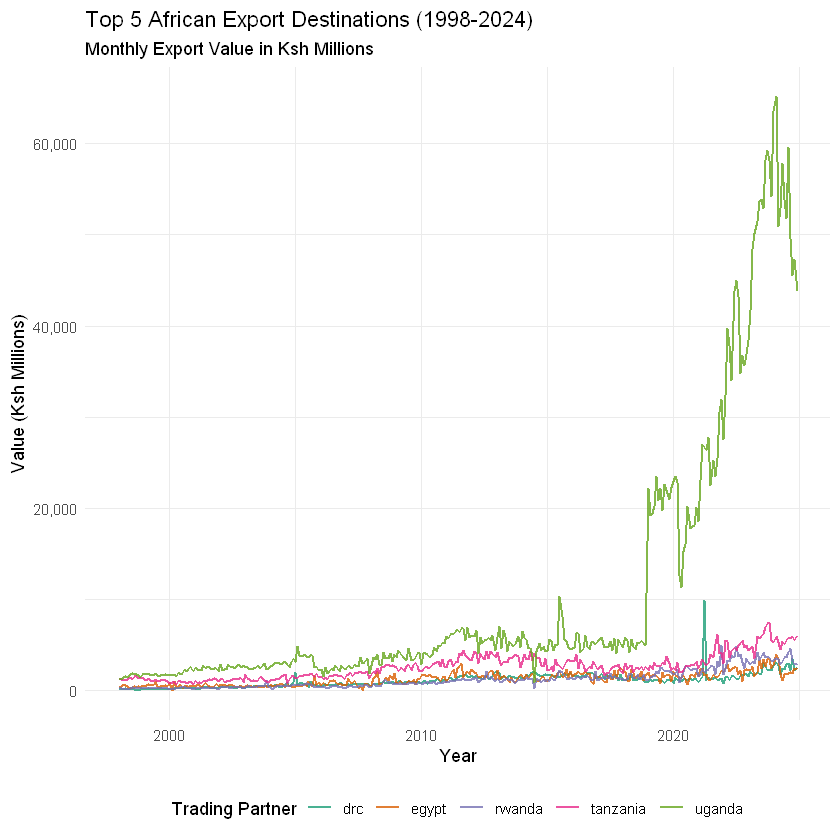

In [3]:
# 1. Reshape data for the Top 5 partners
df_top_african <- df_african %>%
  dplyr::select(date, uganda, tanzania, egypt, rwanda, drc) %>%
  tidyr::pivot_longer(cols = -date, names_to = "Partner", values_to = "Value")

# 2. Plotting the Top 5 Partners
ggplot(df_top_african, aes(x = date, y = Value, color = Partner)) +
  geom_line(linewidth = 0.8, alpha = 0.8) +
  scale_y_continuous(labels = scales::label_comma()) +
  scale_color_brewer(palette = "Dark2") +
  labs(
    title = "Top 5 African Export Destinations (1998-2024)",
    subtitle = "Monthly Export Value in Ksh Millions",
    x = "Year", y = "Value (Ksh Millions)",
    color = "Trading Partner"
  ) +
  theme_minimal() +
  theme(legend.position = "bottom")

## 2. EAC Integration vs. Continental Trade

A strategic insight here by grouping the countries. We'll create an 'EAC Core' (Uganda, Tanzania, Rwanda, DRC) and compare it against the 'Rest of Sampled Africa' (Egypt, South Africa, Ethiopia, etc.).

**The Goal:** To see if Kenya's trade growth is purely a 'neighborly' phenomenon or if it's successfully penetrating distant markets like Egypt or South Africa.

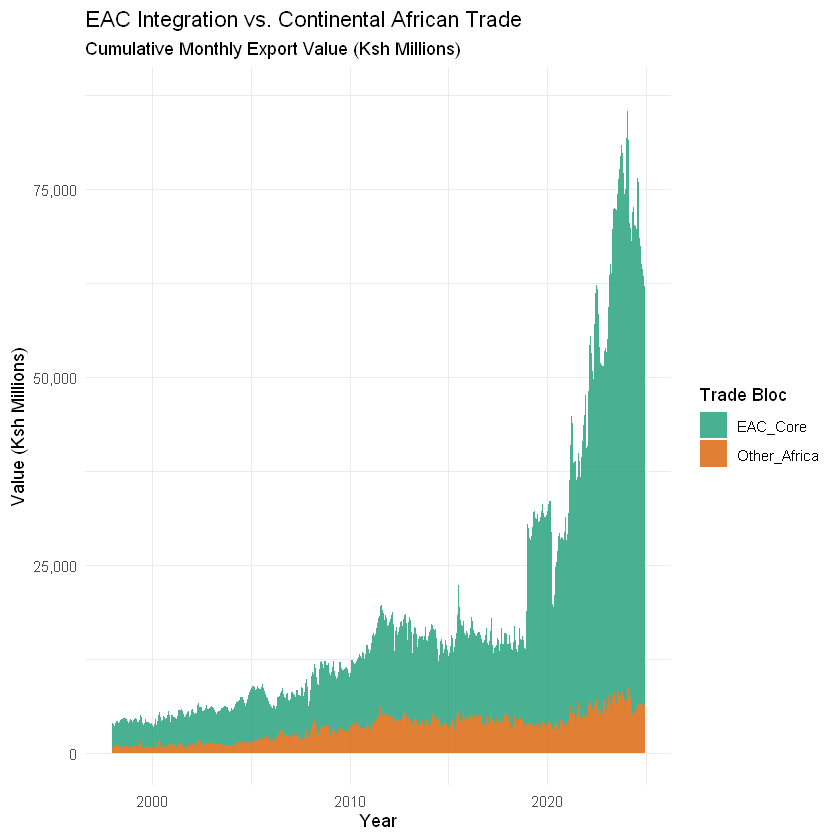

In [4]:
# 1. Creating Aggregated Regions
df_regions <- df_african %>%
  dplyr::mutate(
    EAC_Core = uganda + tanzania + rwanda + drc,
    Other_Africa = egypt + zambia + zimbabwe + ethiopia + somalia + south_africa
  ) %>%
  dplyr::select(date, EAC_Core, Other_Africa) %>%
  tidyr::pivot_longer(cols = -date, names_to = "Region", values_to = "Value")

# 2. Plotting Regional Comparison
ggplot(df_regions, aes(x = date, y = Value, fill = Region)) +
  geom_area(alpha = 0.8) +
  scale_fill_manual(values = c("EAC_Core" = "#1B9E77", "Other_Africa" = "#D95F02")) +
  scale_y_continuous(labels = scales::label_comma()) +
  labs(
    title = "EAC Integration vs. Continental African Trade",
    subtitle = "Cumulative Monthly Export Value (Ksh Millions)",
    x = "Year", y = "Value (Ksh Millions)",
    fill = "Trade Bloc"
  ) +
  theme_minimal()

While there are over 50 countries in Africa, just 4 of Kenya's neighbors (the EAC Core) often account for the vast majority of its continental earnings.

To quantify this 'dominance', we should look at the Percentage Share rather than just the absolute numbers. This tells us exactly how much of Kenya's 'African Egg' is in the 'EAC Basket.'

## 3. Market Concentration (EAC Share of Total Africa Trade)

We are converting the monthly totals into percentages. This allows us to see if Kenya is successfully diversifying away from its neighbors over time, or if its reliance on them is actually increasing.

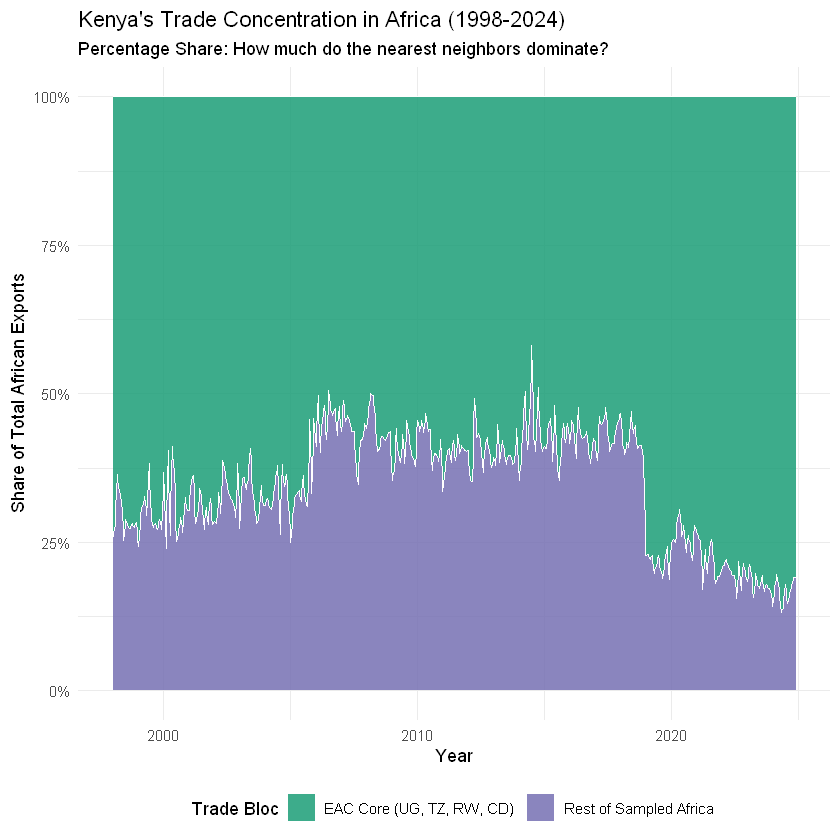

In [5]:
# 1. Calculate Percentage Shares
df_shares <- df_african %>%
  dplyr::mutate(
    # Aggregate the EAC Core members
    EAC_Core_Sum = uganda + tanzania + rwanda + drc,
    # Everything else in Africa is the difference
    Other_Africa_Sum = total - EAC_Core_Sum
  ) %>%
  dplyr::mutate(
    # Calculate percentages
    EAC_Pct = (EAC_Core_Sum / total) * 100,
    Other_Pct = (Other_Africa_Sum / total) * 100
  ) %>%
  dplyr::select(date, EAC_Pct, Other_Pct) %>%
  tidyr::pivot_longer(cols = -date, names_to = "Region", values_to = "Percentage")

# 2. Plotting the 100% Stacked Area Chart
ggplot(df_shares, aes(x = date, y = Percentage, fill = Region)) +
  geom_area(alpha = 0.85, color = "white", linewidth = 0.1) +
  scale_fill_manual(
    values = c("EAC_Pct" = "#1B9E77", "Other_Pct" = "#7570B3"),
    labels = c("EAC Core (UG, TZ, RW, CD)", "Rest of Sampled Africa")
  ) +
  scale_y_continuous(labels = scales::percent_format(scale = 1)) +
  labs(
    title = "Kenya's Trade Concentration in Africa (1998-2024)",
    subtitle = "Percentage Share: How much do the nearest neighbors dominate?",
    x = "Year", y = "Share of Total African Exports",
    fill = "Trade Bloc"
  ) +
  theme_minimal() +
  theme(legend.position = "bottom")

### Insights
**The '70% Rule':** The green area (EAC) consistently stays above the 60-70% mark. This shows that Kenya’s export "gravitational pull" is incredibly short-range.

**Structural Shifts:** periods where the "Rest of Africa" (purple) grows often happens when Kenya signs new trade deals (like with Egypt/COMESA) or when a new market like South Africa opens up for Kenyan tea/coffee.

**Stability:** A stable share means that as the whole pie grows, Kenya is growing at the same rate in both its neighborhood and the wider continent.